# Insolation

This notebook is part of [The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook) by [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/), University at Albany.

____________
## 1. Distribution of insolation
____________


:::{note}
These notes closely follow section 2.7 of *Global Physical Climatology* by {cite:t}`Hartmann`.
:::

The **amount of solar radiation** incident on the top of the atmosphere (what we call the "insolation") depends on

- latitude
- season
- time of day

This insolation is the primary driver of the climate system. Here we will examine the geometric factors that determine insolation, focussing primarily on the **daily average** values.

### Solar zenith angle

We define the **solar zenith angle** $\theta_s$ as the angle between the local normal to Earth's surface and a line between a point on Earth's surface and the sun.

![Hartmann Figure 2.5](../images/Hartmann_Fig2.5.png)

From the above figure (reproduced from {cite:t}`Hartmann`), the ratio of the shadow area to the surface area is equal to the cosine of the solar zenith angle.

### Instantaneous solar flux

We can write the solar flux per unit surface area as

$$ Q = S_0 \left( \frac{\overline{d}}{d} \right)^2 \cos \theta_s $$

where $\overline{d}$ is the mean distance for which the flux density $S_0$ (i.e. the solar constant) is measured, and $d$ is the actual distance from the sun.

Question:

- what factors determine $\left( \frac{\overline{d}}{d} \right)^2$ ?
- under what circumstances would this ratio always equal 1?

### Calculating the zenith angle

Just like the flux itself, the solar zenith angle depends latitude, season, and time of day.

#### Declination angle
The seasonal dependence can be expressed in terms of the **declination angle** of the sun: the latitude of the point on the surface of Earth directly under the sun at noon (denoted by $\delta$).

$\delta$ currenly varies between +23.45º at northern summer solstice (June 21) to -23.45º at northern winter solstice (Dec. 21).

#### Hour angle

The **hour angle** $h$ is defined as the longitude of the subsolar point relative to its position at noon.

#### Formula for zenith angle
With these definitions and some spherical geometry (see Appendix A of Hartmann's book), we can express the solar zenith angle for any latitude $\phi$, season, and time of day as

$$ \cos \theta_s = \sin \phi \sin \delta + \cos\phi \cos\delta \cos h $$

#### Sunrise and sunset

If $\cos\theta_s < 0$ then the sun is below the horizon and the insolation is zero (i.e. it's night time!)

Sunrise and sunset occur when the solar zenith angle is 90º and thus $\cos\theta_s=0$. The above formula then gives

$$ \cos h_0 = - \tan\phi \tan\delta $$

where $h_0$ is the hour angle at sunrise and sunset.

#### Polar night

Near the poles special conditions prevail. Latitudes poleward of 90º-$\delta$ are constantly illuminated in summer, when $\phi$ and $\delta$ are of the same sign.  Right at the pole there is 6 months of perpetual daylight in which the sun moves around the compass at a constant angle $\delta$ above the horizon.

In the winter, $\phi$ and $\delta$ are of opposite sign, and latitudes poleward of 90º-$|\delta|$ are in perpetual darkness. At the poles, six months of daylight alternate with six months of daylight.

At the equator day and night are both 12 hours long throughout the year.

### Daily average insolation

Substituting the expression for solar zenith angle into the insolation formula gives the instantaneous insolation as a function of latitude, season, and time of day:

$$ Q = S_0 \left( \frac{\overline{d}}{d} \right)^2 \Big( \sin \phi \sin \delta + \cos\phi \cos\delta \cos h  \Big) $$

which is valid only during daylight hours, $|h| < h_0$, and $Q=0$ otherwise (night).

To get the daily average insolation, we integrate this expression between sunrise and sunset and divide by 24 hours (or $2\pi$ radians since we express the time of day in terms of hour angle):

$$ \overline{Q}^{day} = \frac{1}{2\pi} \int_{-h_0}^{h_0} Q ~dh$$

$$ = \frac{S_0}{2\pi} \left( \frac{\overline{d}}{d} \right)^2 \int_{-h_0}^{h_0} \Big( \sin \phi \sin \delta + \cos\phi \cos\delta \cos h  \Big) ~ dh $$

which is easily integrated to get our formula for daily average insolation:

$$ \overline{Q}^{day} = \frac{S_0}{\pi} \left( \frac{\overline{d}}{d} \right)^2 \Big( h_0 \sin\phi \sin\delta + \cos\phi \cos\delta \sin h_0 \Big)$$

where the hour angle at sunrise/sunset $h_0$ must be in radians.

### The daily average zenith angle

It turns out that, due to optical properties of the Earth's surface (particularly bodies of water), the surface albedo depends on the solar zenith angle. It is therefore useful to consider the average solar zenith angle during daylight hours as a function of latidude and season.

The appropriate daily average here is weighted with respect to the insolation, rather than weighted by time. The formula is

$$ \overline{\cos\theta_s}^{day} = \frac{\int_{-h_0}^{h_0} Q \cos\theta_s~dh}{\int_{-h_0}^{h_0} Q ~dh} $$

{cite:t}`Cronin:2014a` also shows that the insolation-weighted value $\overline{\cos\theta_s}^{day}$ is a good choice for minimizing scattering bias under a variety of circumstances.

To calculate $\overline{\cos\theta_s}^{day}$, we first note that the factor $S_0 \left(\frac{\overline{d}}{d}\right)^2$ cancels out of the top and bottom of the above expression, leaving

$$ \overline{\cos\theta_s}^{Q} = \frac{\int_{-h_0}^{h_0} \cos^2 \theta_s ~dh}{\int_{-h_0}^{h_0} \cos\theta_s ~dh} $$

With a bit of work, we can substitute in the expression for $\cos\theta_s$ in terms of latitude $\phi$, declination angle $\delta$ and hour angle $h$ and integrate the numerator and denominator of the above expression. I implement the resulting formulas in the Python code below

/var/folders/dl/j7hb106d36n501mrm8j646bxpf4y1c/T/ipykernel_75724/797907564.py:14: RuntimeWarning: invalid value encountered in arccos
  arccos(-tan(phi)*tan(delta)),
/var/folders/dl/j7hb106d36n501mrm8j646bxpf4y1c/T/ipykernel_75724/797907564.py:23: RuntimeWarning: invalid value encountered in divide
  return numerator / denominator / 2


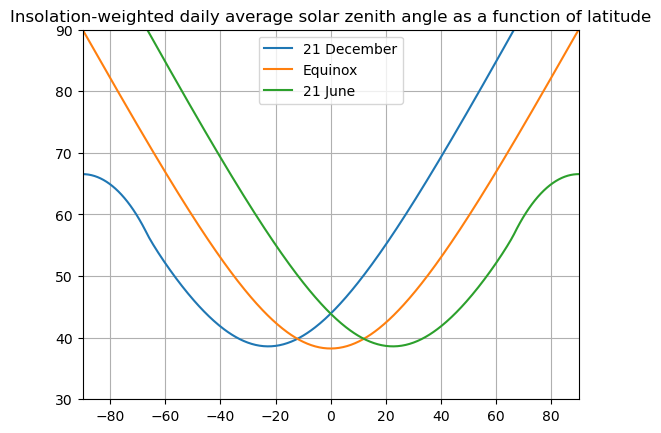

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import sin,cos,tan,arccos,arcsin,arctan,pi,abs

lat = np.linspace(-90., 90, 500)
phi = np.deg2rad(lat)

declinations = {'21 December': -23.45,
                'Equinox': 0.,
                '21 June': 23.45}

def hour_angle_at_sunset(delta, phi):
    return np.where( abs(delta)-pi/2+abs(phi) < 0., # there is sunset/sunrise
              arccos(-tan(phi)*tan(delta)),
              # otherwise figure out if it's all night or all day
              np.where(phi*delta>0., pi, 0.) )

def insolation_weighted_coszen(delta, phi):
    h0 = hour_angle_at_sunset(delta, phi)
    denominator = h0*sin(phi)*sin(delta) + cos(phi)*cos(delta)*sin(h0)
    numerator = (h0*(2* sin(phi)**2*sin(delta)**2 + cos(phi)**2*cos(delta)**2) + 
        cos(phi)*cos(delta)*sin(h0)*(4*sin(phi)*sin(delta) + cos(phi)*cos(delta)*cos(h0)))
    return numerator / denominator / 2

for label, delta in declinations.items():
    plt.plot(lat, np.rad2deg(arccos(insolation_weighted_coszen(np.deg2rad(delta), phi))), label=label)
plt.legend()
plt.grid()
plt.title('Insolation-weighted daily average solar zenith angle as a function of latitude');
plt.ylim(30,90);
plt.xlim(-90,90);

_The figure above reproduces Figure 2.8 from {cite:p}`Hartmann`._

The average zenith angle is much higher at the poles than in the tropics. This contributes to the very high surface albedos observed at high latitudes.

____________
## 2. Computing daily insolation with `climlab`
____________

Here are some examples calculating daily average insolation at different locations and times.

These all use a function called 
```
daily_insolation
``` 
in the package 
```
climlab.solar.insolation
``` 
to do the calculation. The code implements the above formulas to calculates daily average insolation anywhere on Earth at any time of year.

The code takes account of *orbital parameters* to calculate current Sun-Earth distance.  

We can look up *past orbital variations* to compute their effects on insolation using the package 
```
climlab.solar.orbital
```
See the [next lecture](orbital)!

### Using the `daily_insolation` function

In [2]:
from climlab import constants as const
from climlab.solar.insolation import daily_insolation

First, get a little help on using the `daily_insolation` function:

In [3]:
help(daily_insolation)

Help on function daily_insolation in module climlab.solar.insolation:

daily_insolation(
    lat,
    day,
    orb={'ecc': 0.017236, 'long_peri': 281.37, 'obliquity': 23.446},
    S0=1365.2,
    day_type=1,
    days_per_year=365.2422
)
    Compute daily average insolation given latitude, time of year and orbital parameters.

    Orbital parameters can be interpolated to any time in the last 5 Myears with
    ``climlab.solar.orbital.OrbitalTable`` (see example above).

    Longer orbital tables are available with ``climlab.solar.orbital.LongOrbitalTable``

    Inputs can be scalar, ``numpy.ndarray``, or ``xarray.DataArray``.

    The return value will be ``numpy.ndarray`` if **all** the inputs are ``numpy``.
    Otherwise ``xarray.DataArray``.

    **Function-call argument**


    :param array lat:       Latitude in degrees (-90 to 90).
    :param array day:       Indicator of time of year. See argument ``day_type``
                            for details about format.
    :param dict o

Here are a few simple examples.

First, compute the daily average insolation at 45ºN on January 1:

In [4]:
daily_insolation(45,1)

np.float64(123.95321551807461)

Same location, July 1:

In [5]:
daily_insolation(45,181)

np.float64(482.356497522712)

We could give an array of values. Let's calculate and plot insolation at all latitudes on the spring equinox = March 21 = Day 80

Text(0.5, 1.0, 'Daily average insolation on March 21')

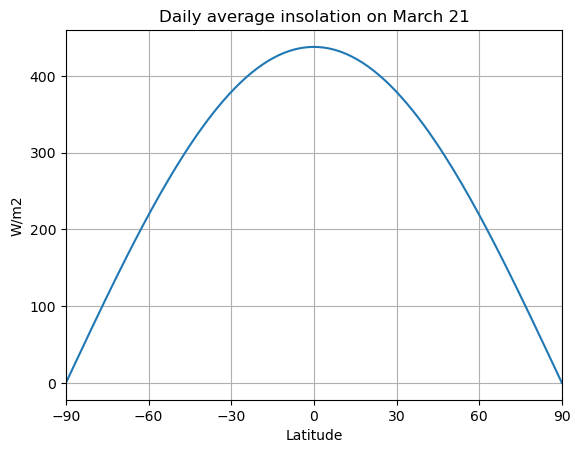

In [6]:
lat = np.linspace(-90., 90., 180)
Q = daily_insolation(lat, 80)
fig, ax = plt.subplots()
ax.plot(lat,Q)
ax.set_xlim(-90,90); ax.set_xticks([-90,-60,-30,-0,30,60,90])
ax.set_xlabel('Latitude')
ax.set_ylabel('W/m2')
ax.grid()
ax.set_title('Daily average insolation on March 21')

### Using real calendar dates

The `day` input to the `daily_insolation` function is not tied to a specific calendar year, it's really just measuring the length of time (in fractional days) from the Spring Equinox (which is defined as day 80).

Real calendar years have variable lengths (i.e. leap years).

Fortunately there are some easy-to-use software packages to help manage dates and times in Python. Here we're going to use some numpy functionality through the `np.datetime64` and `np.timedelta64` data types.

First we define a helper function to translate from an actual calendar date / time to the day index needed by the solar calculator:

In [7]:
def dates_to_day_index(datetime):
    '''Convert dates and time (assumed to be UTC) to a fractional number of days
    from a hypothetical January 1 00h that is exactly 80 days before the spring equinox.

    Input datetime is a np.datetime64 object (or array of these)

    Output is array of floats.
    '''
    # Precise time of the most recent Spring Equinox in 9:01 UTC on March 20 2025
    spring_equinox = np.datetime64('2025-03-20T09:01')  
    time_since_equinox = datetime - spring_equinox
    time_since_jan1 = time_since_equinox + np.timedelta64(80, 'D')
    return time_since_jan1 / np.timedelta64(1, 'D')  # result as fractional days

Now we'll define a datetime object to represent a particular calendar date and plot the insolation at all latitudes:

In [8]:
# Here we generate a datetime64 object with a specific date:
Oct15 = np.datetime64('2025-10-15') 
Oct15

np.datetime64('2025-10-15')

Text(0.5, 1.0, 'Daily average insolation at 2025-10-15')

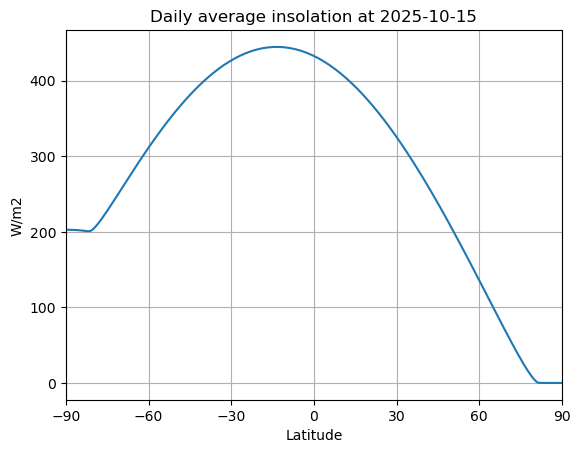

In [9]:
Q = daily_insolation(lat, dates_to_day_index(Oct15))
fig, ax = plt.subplots()
ax.plot(lat,Q)
ax.set_xlim(-90,90); ax.set_xticks([-90,-60,-30,-0,30,60,90])
ax.set_xlabel('Latitude')
ax.set_ylabel('W/m2')
ax.grid()
ax.set_title('Daily average insolation at {}'.format(Oct15))

### In-class exercises

Try to answer the following questions **before reading the rest of these notes**.

- What is the daily insolation today here at Albany (latitude 42.65ºN)?
- What is the **annual mean** insolation at the latitude of Albany?
- At what latitude and at what time of year does the **maximum daily insolation** occur?
- What latitude is experiencing either **polar sunrise** or **polar sunset** today?

____________
## 3. Global, seasonal distribution of insolation (present-day orbital parameters)
____________

Calculate an array of insolation over the year and all latitudes (for present-day orbital parameters). We'll use a dense grid in order to make a nice contour plot

In [10]:
lat = np.linspace( -90., 90., 500)
days = np.arange(0., 1., 0.001) * const.days_per_year

Q = daily_insolation( lat, days )

And make a contour plot of Q as function of latitude and time of year.

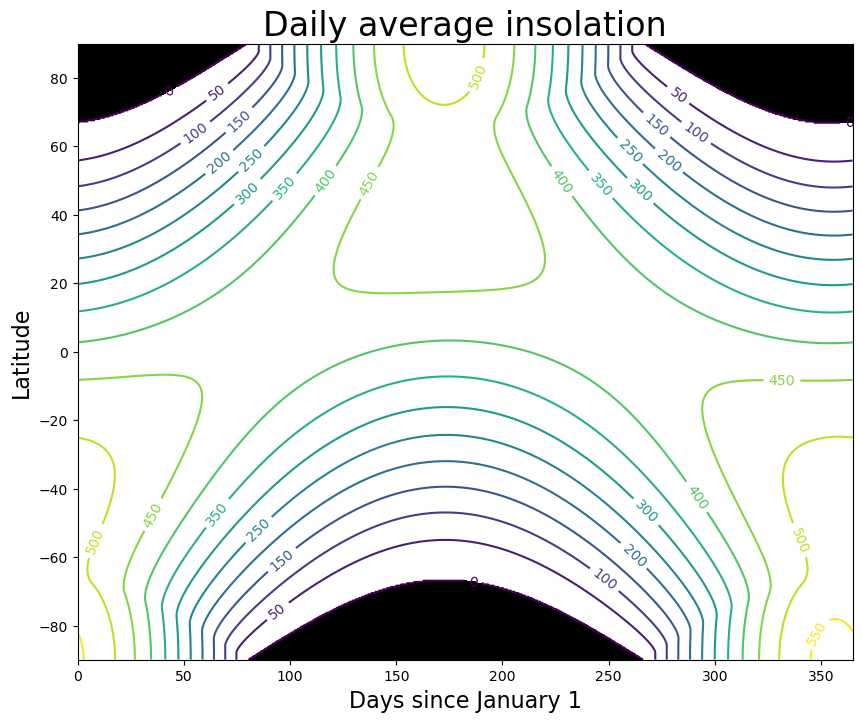

In [11]:
fig, ax = plt.subplots(figsize=(10,8))
CS = ax.contour( days, lat, Q , levels = np.arange(0., 600., 50.) )
ax.clabel(CS, CS.levels, inline=True, fmt='%1.0f', fontsize=10)
ax.set_xlabel('Days since January 1', fontsize=16 )
ax.set_ylabel('Latitude', fontsize=16 )
ax.set_title('Daily average insolation', fontsize=24 )
ax.contourf ( days, lat, Q, levels=[-1000., 0.], colors='k' )

### Time and space averages

Take the area-weighted global, annual average of Q...

In [12]:
Qaverage = np.average(np.mean(Q, axis=1), weights=np.cos(np.deg2rad(lat)))
print( 'The annual, global average insolation is %.2f W/m2.' %Qaverage)

The annual, global average insolation is 341.35 W/m2.


Also plot the zonally averaged insolation at a few different times of the year:

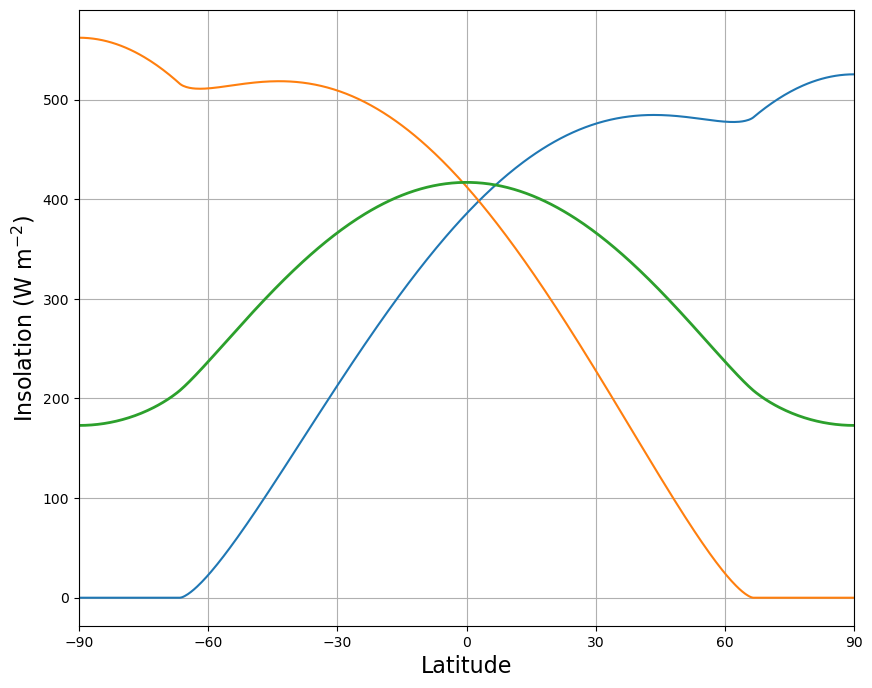

In [13]:
summer_solstice = 472  # index of the solstice along this time axis
winter_solstice = 976  # and same for winter solstice
fig, ax = plt.subplots(figsize=(10,8))
ax.plot( lat, Q[:,(summer_solstice, winter_solstice)] );
ax.plot( lat, np.mean(Q, axis=1), linewidth=2 )
ax.set_xbound(-90, 90)
ax.set_xticks( range(-90,100,30) )
ax.set_xlabel('Latitude', fontsize=16 );
ax.set_ylabel('Insolation (W m$^{-2}$)', fontsize=16 );
ax.grid()

____________

## Credits

This notebook is part of [The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook), an open-source textbook developed and maintained by [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/), University at Albany.

It is licensed for free and open consumption under the
[Creative Commons Attribution 4.0 International (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/) license.

Development of these notes and the [climlab software](https://github.com/climlab/climlab) is partially supported by the National Science Foundation under award AGS-1455071 to Brian Rose. Any opinions, findings, conclusions or recommendations expressed here are mine and do not necessarily reflect the views of the National Science Foundation.
____________